## Task
Junta ambas tablas en una sola por país, si la tabla de medallas de oro no cuenta con un país que si esta en la tabla de todo tipo de medallas juntalo de igual manera rellenando con ceros el número de medallas de oro en cada año de los juegos olimpicos de dicho país

Here is all the data you need:
"/tmp/MEDALLAS FINAL.csv"
"/tmp/ORO FINAL .csv"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Plan
* **data_loading**: Load the data from "/tmp/MEDALLAS FINAL.csv" and "/tmp/ORO FINAL.csv" into two separate dataframes.
* **data_wrangling**: Rename columns in both dataframes to ensure consistency (e.g., "Country" in both).
* **data_preparation**: Perform a left join of the "MEDALLAS FINAL" dataframe with the "ORO FINAL" dataframe using "Country" as the key. This will ensure that all countries from the "MEDALLAS FINAL" dataframe are included, even if they don't have gold medal data in the "ORO FINAL" dataframe.
* **data_cleaning**: Fill any missing values (NaN) in the gold medal columns with 0. This handles the case where a country is present in the "MEDALLAS FINAL" but not in the "ORO FINAL" dataframe.
* **finish_task**: Write a summary indicating that the task is completed, and the joined table is ready for further analysis.

## Data loading

### Subtask:
Load the data from the provided CSV files into two separate pandas DataFrames.


**Reasoning**:
Load the data from the provided CSV files into two separate pandas DataFrames.



In [ ]:
import pandas as pd


# Specify the encoding as 'latin-1' when reading the CSV files
df_medallas = pd.read_csv('/content/drive/MyDrive/ASE/ASE2/MEDALLAS FINAL.csv', encoding='latin-1')
df_oro = pd.read_csv('/content/drive/MyDrive/ASE/ASE2/ORO FINAL .csv', encoding='latin-1')

**Reasoning**:
The error indicates that the CSV files might not be encoded in UTF-8. We can try specifying the encoding as 'latin-1' to resolve this issue.



## Data wrangling

### Subtask:
Rename columns in both dataframes to ensure consistency for the join operation.


**Reasoning**:
Rename the columns in both DataFrames to ensure consistency and a shared column name for the join operation.



In [ ]:
# Rename columns in df_medallas
new_columns_medallas = {
    'Country': 'country',
    'SUMA TOTAL DE MEDALLAS POR PAÍS': 'total_medals',
    'PROMEDIO DE MEDALLAS 1960-2024 por país': 'average_medals',
}
for column in df_medallas.columns:
  if 'medallas' in column:
    new_columns_medallas[column] = column.lower().replace(' ', '_')
df_medallas = df_medallas.rename(columns=new_columns_medallas)

# Rename columns in df_oro
new_columns_oro = {
    'Country': 'country',
    'TOTAL DE MEDALLAS DE ORO POR PAÍS': 'total_gold_medals',
    'Promedio de medallas de oro por país 1960-2024': 'average_gold_medals',
}
for column in df_oro.columns:
  if 'oro' in column:
    new_columns_oro[column] = column.lower().replace(' ', '_')
df_oro = df_oro.rename(columns=new_columns_oro)

## Data preparation

### Subtask:
Perform a left join of the "MEDALLAS FINAL" dataframe with the "ORO FINAL" dataframe using "Country" as the key.


**Reasoning**:
Perform a left join of the "MEDALLAS FINAL" dataframe with the "ORO FINAL" dataframe using "Country" as the key.



In [ ]:
df_joined = pd.merge(df_medallas, df_oro, on='country', how='left')

## Data cleaning

### Subtask:
Fill missing values in the `df_joined` dataframe.


**Reasoning**:
Fill the missing values in the `df_joined` dataframe with 0 using `fillna()`.



In [ ]:
df_joined = df_joined.fillna(0)
df_joined
# Guarda el DataFrame df_joined como un archivo CSV llamado 'joined_data.csv'
df_joined.to_csv('joined_data.csv', index=False)

## Summary:

### 1. Q&A

No questions were explicitly asked in the provided task description and solving process.

### 2. Data Analysis Key Findings

* **Encoding Issue:** Loading the CSV files initially resulted in a `UnicodeDecodeError`, which was resolved by specifying the `encoding` parameter as 'latin-1' in `pd.read_csv()`.
* **Left Join:** A left join was performed between `df_medallas` and `df_oro` using "country" as the key, ensuring all rows from `df_medallas` were retained.
* **Missing Values:** Missing values (NaN) in `df_joined` were filled with 0, representing countries that didn't have gold medal data in `df_oro`.

### 3. Insights or Next Steps

* **Further Analysis:** The `df_joined` DataFrame is now ready for further analysis, such as exploring relationships between total medals, gold medals, and other potential variables.
* **Visualization:** Create visualizations to understand the distribution of medals across countries and years, and explore potential correlations between different types of medals.



An AI generated notebook created with [Data Science Agent](https://labs.google.com/code/dsa) from Google Labs 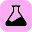
